# HMSA-UNet3D — Segmentation de Tumeurs Cérébrales 3D (BraTS 2021)
**PFE Master** — *Modèle 3D avancé de segmentation tumorale basé sur U-Net avec attention multi-échelle*

Inclut : cache `.npy` (vitesse), **augmentation avancée** (flips, intensité, rotation, affine, déformation élastique),
architecture HMSA-UNet3D (CBAM + Self-Attention 3D + Attention Gates + supervision profonde),
métriques **Dice / IoU / Sensibilité / HD95**, aperçu de patients nets, prédictions, **Grad-CAM 3D** (XAI) et sauvegarde.

> GPU obligatoire (Settings → Accelerator → GPU). Ajoute le dataset BraTS 2021 (Add Input).

## 1. Installation & imports

In [1]:
import sys, subprocess
try:
    import nibabel  # noqa
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nibabel"])

import os, glob, random, time, tarfile, shutil
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm  # mode texte : évite l'erreur "Error displaying widget" sur Kaggle
from scipy.ndimage import (rotate, gaussian_filter, map_coordinates, affine_transform,
                           binary_erosion, distance_transform_edt)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
else:
    print("ATTENTION : pas de GPU -> active l'accélérateur GPU dans Settings.")

Device : cuda
GPU    : Tesla T4


## 2. Configuration

In [2]:
class CFG:
    # --- Données ---
    DATA_ROOT    = None
    CROP_SIZE    = (128, 128, 128)
    MODALITIES   = ["flair", "t1", "t1ce", "t2"]
    MAX_PATIENTS = None
    VAL_SPLIT    = 0.2
    EXCLUDE_PATIENTS = ["BraTS2021_00495", "BraTS2021_00621"]   # patients à NE PAS utiliser

    # --- Cache ---
    USE_CACHE    = True
    CACHE_DIR    = "/kaggle/temp/brats_cache"

    # --- Augmentation (probabilités par transformation) ---
    AUG_FLIP      = 0.5
    AUG_INTENSITY = 0.5
    AUG_ROTATE    = 0.3     # rotation aléatoire (<= 15°)
    AUG_AFFINE    = 0.2     # scale + cisaillement
    AUG_ELASTIC   = 0.15    # déformation élastique (coûteuse : baisse si l'epoch est lente)

    # --- Modèle ---
    IN_CHANNELS  = 4
    NUM_CLASSES  = 4
    BASE_CH      = 32       # 16 si "CUDA out of memory"
    NUM_HEADS    = 4
    DEEP_SUP     = True

    # --- Entraînement ---
    EPOCHS       = 30
    BATCH_SIZE   = 1
    LR           = 1e-4
    WEIGHT_DECAY = 1e-5
    NUM_WORKERS  = 4
    AMP          = True
    DS_WEIGHTS   = (1.0, 0.5, 0.25)
    CKPT_PATH    = "/kaggle/working/hmsa_unet3d_best.pth"

    # --- HD95 (Hausdorff 95%) ---
    EVAL_HD95    = True     # calculer HD95 en validation
    HD95_EVERY   = 1        # tous les N epochs (mets 5 si la validation est lente)

cfg = CFG()
print("Crop:", cfg.CROP_SIZE, "| Base:", cfg.BASE_CH, "| Cache:", cfg.USE_CACHE, "| HD95:", cfg.EVAL_HD95)

Crop: (128, 128, 128) | Base: 32 | Cache: True | HD95: True


## 3. Localisation des données + exclusion de patients

In [3]:
def find_patient_folders(root):
    f = sorted(glob.glob(os.path.join(root, "**", "BraTS2021_*"), recursive=True))
    return [p for p in f if os.path.isdir(p)]

def auto_detect_root():
    if cfg.DATA_ROOT and os.path.isdir(cfg.DATA_ROOT):
        f = find_patient_folders(cfg.DATA_ROOT)
        if f: return cfg.DATA_ROOT, f
    for root, dirs, _ in os.walk("/kaggle/input"):
        if any(d.startswith("BraTS2021_") for d in dirs):
            f = find_patient_folders(root)
            if f: return root, f
    tars = glob.glob("/kaggle/input/**/BraTS2021_Training_Data.tar", recursive=True)
    if tars:
        ex = "/kaggle/temp/brats21"; os.makedirs(ex, exist_ok=True)
        if not find_patient_folders(ex):
            print("Extraction du .tar ...")
            with tarfile.open(tars[0]) as t: t.extractall(ex, filter="data")
        return ex, find_patient_folders(ex)
    return None, []

DATA_ROOT, patient_folders = auto_detect_root()
assert patient_folders, "Aucun patient trouvé : ajoute le dataset BraTS 2021 (Add Input) ou renseigne cfg.DATA_ROOT."

before = len(patient_folders)
patient_folders = [f for f in patient_folders if os.path.basename(f) not in cfg.EXCLUDE_PATIENTS]
print("Racine :", DATA_ROOT, "| Patients :", len(patient_folders),
      f"({before-len(patient_folders)} exclu(s) : {cfg.EXCLUDE_PATIENTS})")

Extraction du .tar ...
Racine : /kaggle/temp/brats21 | Patients : 1249 (2 exclu(s) : ['BraTS2021_00495', 'BraTS2021_00621'])


## 4. Prétraitement & Dataset (cache + augmentation avancée)
Resizing (crop centré → 128³), z-score par modalité, remap `4→3`.
**Augmentation** (train uniquement) : flips, variation d'intensité, **rotation**, **affine** (échelle + cisaillement)
et **déformation élastique**. L'image utilise une interpolation linéaire (order=1) et le masque une interpolation
au plus proche voisin (order=0) pour préserver les étiquettes.

In [4]:
def load_case(folder, modalities):
    pid = os.path.basename(folder)
    imgs = [nib.load(os.path.join(folder, f"{pid}_{m}.nii.gz")).get_fdata().astype(np.float32)
            for m in modalities]
    seg = nib.load(os.path.join(folder, f"{pid}_seg.nii.gz")).get_fdata().astype(np.uint8)
    return np.stack(imgs, 0), seg

def crop_or_pad_center(image, seg, size):
    _, H, W, D = image.shape; th, tw, td = size
    def fx(L, T):
        if L >= T:
            s = (L - T) // 2; return slice(s, s + T), 0, 0
        b = (T - L) // 2; return slice(0, L), b, T - L - b
    sh, pbh, pah = fx(H, th); sw, pbw, paw = fx(W, tw); sd, pbd, pad_ = fx(D, td)
    image = image[:, sh, sw, sd]; seg = seg[sh, sw, sd]
    pad = ((0, 0), (pbh, pah), (pbw, paw), (pbd, pad_))
    return np.pad(image, pad), np.pad(seg, pad[1:])

def znorm(image):
    out = np.zeros_like(image, np.float32)
    for c in range(image.shape[0]):
        v = image[c]; m = v > 0
        if m.sum() > 0:
            out[c] = np.where(m, (v - v[m].mean()) / (v[m].std() + 1e-8), 0.0)
    return out

# ---- Transformations géométriques (mêmes paramètres pour image et masque) ----
def aug_rotate(image, seg, max_angle=15):
    planes_i = [(1,2),(1,3),(2,3)]; planes_s = [(0,1),(0,2),(1,2)]
    k = random.randint(0, 2); ang = random.uniform(-max_angle, max_angle)
    image = rotate(image, ang, axes=planes_i[k], reshape=False, order=1, mode="constant")
    seg   = rotate(seg,   ang, axes=planes_s[k], reshape=False, order=0, mode="constant")
    return image, seg

def aug_affine(image, seg, max_scale=0.1, max_shear=0.1):
    M = np.eye(3)
    M += np.random.uniform(-max_shear, max_shear, (3,3)) * (1 - np.eye(3))
    M[np.diag_indices(3)] *= np.random.uniform(1 - max_scale, 1 + max_scale, 3)
    center = np.array(image.shape[1:]) / 2.0; offset = center - M @ center
    img = np.stack([affine_transform(image[c], M, offset=offset, order=1, mode="constant")
                    for c in range(image.shape[0])])
    sg = affine_transform(seg.astype(np.float32), M, offset=offset, order=0, mode="constant").astype(seg.dtype)
    return img, sg

def aug_elastic(image, seg, alpha=15, sigma=4):
    shape = image.shape[1:]
    d = [gaussian_filter(np.random.rand(*shape)*2-1, sigma)*alpha for _ in range(3)]
    g = np.meshgrid(*[np.arange(s) for s in shape], indexing="ij")
    idx = [np.reshape(g[i] + d[i], -1) for i in range(3)]
    img = np.stack([map_coordinates(image[c], idx, order=1, mode="constant").reshape(shape)
                    for c in range(image.shape[0])])
    sg = map_coordinates(seg, idx, order=0, mode="constant").reshape(shape)
    return img, sg

def augment(image, seg):
    if random.random() < cfg.AUG_ROTATE:   image, seg = aug_rotate(image, seg)
    if random.random() < cfg.AUG_AFFINE:    image, seg = aug_affine(image, seg)
    if random.random() < cfg.AUG_ELASTIC:   image, seg = aug_elastic(image, seg)
    for ax in (1, 2, 3):
        if random.random() < cfg.AUG_FLIP:
            image = np.flip(image, ax); seg = np.flip(seg, ax - 1)
    if random.random() < cfg.AUG_INTENSITY:
        image = image * random.uniform(0.9, 1.1) + random.uniform(-0.1, 0.1)
    return np.ascontiguousarray(image), np.ascontiguousarray(seg)

class BraTSDataset(Dataset):
    def __init__(self, folders, training=True):
        self.folders = folders; self.training = training
    def __len__(self): return len(self.folders)
    def _paths(self, folder):
        pid = os.path.basename(folder)
        return (os.path.join(cfg.CACHE_DIR, pid + "_img.npy"),
                os.path.join(cfg.CACHE_DIR, pid + "_seg.npy"))
    def _get_processed(self, folder):
        ip, sp = self._paths(folder)
        if cfg.USE_CACHE and os.path.exists(ip) and os.path.exists(sp):
            return np.load(ip).astype(np.float32), np.load(sp)
        image, seg = load_case(folder, cfg.MODALITIES)
        image, seg = crop_or_pad_center(image, seg, cfg.CROP_SIZE)
        seg[seg == 4] = 3
        image = znorm(image)
        if cfg.USE_CACHE:
            os.makedirs(cfg.CACHE_DIR, exist_ok=True)
            np.save(ip, image.astype(np.float16)); np.save(sp, seg.astype(np.uint8))
        return image, seg
    def __getitem__(self, idx):
        image, seg = self._get_processed(self.folders[idx])
        seg = seg.astype(np.int64)
        if self.training:
            image, seg = augment(image, seg)
        return torch.from_numpy(np.ascontiguousarray(image)).float(), torch.from_numpy(np.ascontiguousarray(seg))

# lecture rapide du seg seul (pour sélectionner les patients nets)
def quick_seg(folder):
    _, sp = BraTSDataset([], False)._paths(folder)
    if cfg.USE_CACHE and os.path.exists(sp): return np.load(sp)
    return BraTSDataset([folder], False)._get_processed(folder)[1]

_img, _seg = BraTSDataset([patient_folders[0]], training=False)[0]
print("Image:", tuple(_img.shape), "| Seg:", tuple(_seg.shape), "| Labels:", torch.unique(_seg).tolist())

Image: (4, 128, 128, 128) | Seg: (128, 128, 128) | Labels: [0, 1, 2, 3]


## 5. Découpage Train / Validation

In [5]:
folders = patient_folders[:]
random.shuffle(folders)
if cfg.MAX_PATIENTS:
    folders = folders[:cfg.MAX_PATIENTS]
n_val = int(len(folders) * cfg.VAL_SPLIT)
val_folders, train_folders = folders[:n_val], folders[n_val:]
print(f"Train: {len(train_folders)} | Validation: {len(val_folders)}")

Train: 1000 | Validation: 249


## 6. Pré-traitement & mise en cache (une seule fois)
Convertit tous les patients en `.npy`. Lent une fois (~30-45 min pour le dataset complet), puis chaque epoch devient 3-5× plus rapide.

In [6]:
def build_cache(all_folders):
    if not cfg.USE_CACHE:
        print("Cache désactivé."); return
    os.makedirs(cfg.CACHE_DIR, exist_ok=True)
    loader = DataLoader(BraTSDataset(all_folders, training=False), batch_size=1,
                        shuffle=False, num_workers=cfg.NUM_WORKERS)
    for _ in tqdm(loader, total=len(all_folders), desc="Cache prétraitement"):
        pass

t0 = time.time(); build_cache(train_folders + val_folders)
print(f"Cache prêt en {(time.time()-t0)/60:.1f} min -> {cfg.CACHE_DIR}")

Cache prétraitement: 100%|██████████| 1249/1249 [07:19<00:00,  2.84it/s]

Cache prêt en 7.3 min -> /kaggle/temp/brats_cache


## 7. DataLoaders

In [7]:
train_ds = BraTSDataset(train_folders, training=True)
val_ds   = BraTSDataset(val_folders,   training=False)
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS,
                          pin_memory=True, drop_last=True, persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=cfg.NUM_WORKERS,
                          pin_memory=True, persistent_workers=True, prefetch_factor=2)
print("DataLoaders prêts.")

DataLoaders prêts.


## 8. Aperçu des données — patients les plus nets (avant l'entraînement)
Au lieu de prendre les premiers patients, on **sélectionne ceux dont la tumeur est la plus étendue et la plus visible**
(volume tumoral le plus grand), pour un aperçu clair. Affiche les 4 modalités + la segmentation.

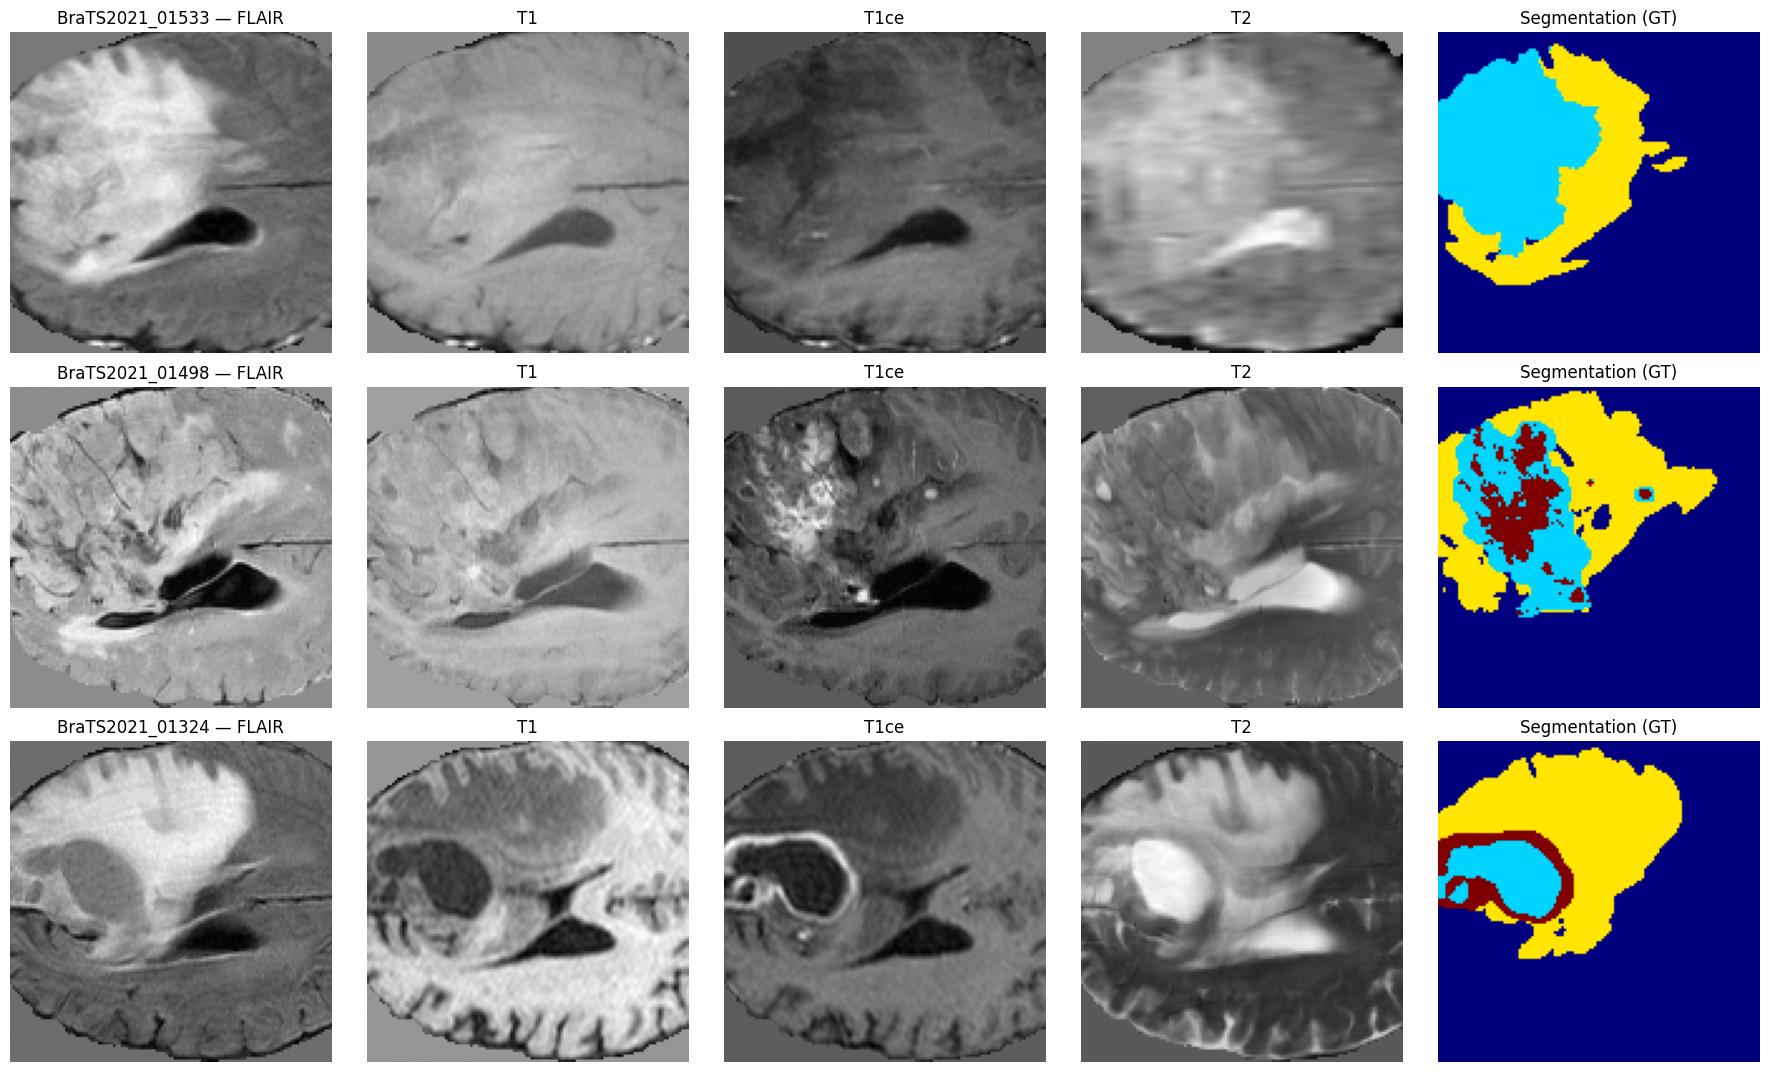

In [8]:
def best_slice(seg):
    areas = (seg > 0).sum(axis=(0, 1))
    return int(areas.argmax()) if areas.max() > 0 else seg.shape[2] // 2

def pick_clear_folders(folder_list, n=3):
    scores = [( (quick_seg(f) > 0).sum(), i) for i, f in enumerate(folder_list)]
    scores.sort(reverse=True)
    return [folder_list[i] for _, i in scores[:n]]

def pick_clear_val_indices(n=3):
    scores = [((quick_seg(f) > 0).sum(), i) for i, f in enumerate(val_folders)]
    scores.sort(reverse=True)
    return [i for _, i in scores[:n]]

def visualize_patients(folder_list, n=3):
    chosen = pick_clear_folders(folder_list, n)
    helper = BraTSDataset(chosen, training=False)
    titles = ["FLAIR", "T1", "T1ce", "T2", "Segmentation (GT)"]
    fig, axes = plt.subplots(len(chosen), 5, figsize=(18, 3.6 * len(chosen)))
    if len(chosen) == 1: axes = axes[None, :]
    for i, f in enumerate(chosen):
        image, seg = helper._get_processed(f); z = best_slice(seg)
        for c in range(4):
            axes[i, c].imshow(image[c, :, :, z], cmap="gray"); axes[i, c].axis("off")
            axes[i, c].set_title(f"{os.path.basename(f)} — {titles[c]}" if c == 0 else titles[c])
        axes[i, 4].imshow(seg[:, :, z], cmap="jet", vmin=0, vmax=3); axes[i, 4].axis("off"); axes[i, 4].set_title(titles[4])
    plt.tight_layout(); plt.show()

visualize_patients(train_folders, n=3)

## 9. CBAM 3D

In [9]:
class ChannelAttention3D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool3d(1); self.mx = nn.AdaptiveMaxPool3d(1)
        h = max(channels // reduction, 4)
        self.mlp = nn.Sequential(nn.Conv3d(channels, h, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv3d(h, channels, 1, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x): return x * self.sig(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))

class SpatialAttention3D(nn.Module):
    def __init__(self, k=7):
        super().__init__(); self.conv = nn.Conv3d(2, 1, k, padding=k // 2, bias=False); self.sig = nn.Sigmoid()
    def forward(self, x):
        a = torch.mean(x, 1, keepdim=True); m, _ = torch.max(x, 1, keepdim=True)
        return x * self.sig(self.conv(torch.cat([a, m], 1)))

class CBAM3D(nn.Module):
    def __init__(self, channels, reduction=16, k=7):
        super().__init__(); self.ca = ChannelAttention3D(channels, reduction); self.sa = SpatialAttention3D(k)
    def forward(self, x): return self.sa(self.ca(x))

## 10. ConvBlock3D résiduel + Attention Gate + Self-Attention 3D

In [10]:
class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, use_cbam=True):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False); self.bn1 = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False); self.bn2 = nn.BatchNorm3d(out_ch)
        self.relu = nn.ReLU(inplace=True); self.use_cbam = use_cbam
        if use_cbam: self.cbam = CBAM3D(out_ch)
        self.res = nn.Conv3d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        idt = self.res(x)
        o = self.relu(self.bn1(self.conv1(x))); o = self.bn2(self.conv2(o))
        if self.use_cbam: o = self.cbam(o)
        return self.relu(o + idt)

class AttentionGate3D(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, 1), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, 1), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, 1), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x): return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class SelfAttention3D(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__(); assert channels % num_heads == 0
        self.h = num_heads; self.norm = nn.GroupNorm(1, channels)
        self.qkv = nn.Conv3d(channels, channels * 3, 1, bias=False); self.proj = nn.Conv3d(channels, channels, 1)
    def forward(self, x):
        B, C, D, H, W = x.shape; n = D * H * W; ch = C // self.h
        qkv = self.qkv(self.norm(x)).view(B, 3, self.h, ch, n)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        att = (torch.matmul(q.transpose(-2, -1), k) / (ch ** 0.5)).softmax(-1)
        out = torch.matmul(v, att.transpose(-2, -1)).reshape(B, C, D, H, W)
        return x + self.proj(out)

## 11. Architecture complète HMSA-UNet3D

In [11]:
class HMSA_UNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, base=32, deep_supervision=True, num_heads=4):
        super().__init__(); self.deep_supervision = deep_supervision
        c1, c2, c3, c4, c5 = base, base*2, base*4, base*8, base*16
        self.enc1 = ConvBlock3D(in_channels, c1); self.enc2 = ConvBlock3D(c1, c2)
        self.enc3 = ConvBlock3D(c2, c3);          self.enc4 = ConvBlock3D(c3, c4)
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3D(c4, c5); self.self_attn = SelfAttention3D(c5, num_heads)
        self.up4 = nn.ConvTranspose3d(c5, c4, 2, 2); self.ag4 = AttentionGate3D(c4, c4, c4//2); self.dec4 = ConvBlock3D(c4*2, c4)
        self.up3 = nn.ConvTranspose3d(c4, c3, 2, 2); self.ag3 = AttentionGate3D(c3, c3, c3//2); self.dec3 = ConvBlock3D(c3*2, c3)
        self.up2 = nn.ConvTranspose3d(c3, c2, 2, 2); self.ag2 = AttentionGate3D(c2, c2, c2//2); self.dec2 = ConvBlock3D(c2*2, c2)
        self.up1 = nn.ConvTranspose3d(c2, c1, 2, 2); self.ag1 = AttentionGate3D(c1, c1, c1//2); self.dec1 = ConvBlock3D(c1*2, c1)
        self.out_conv = nn.Conv3d(c1, num_classes, 1)
        if deep_supervision:
            self.aux2 = nn.Conv3d(c2, num_classes, 1); self.aux3 = nn.Conv3d(c3, num_classes, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.self_attn(self.bottleneck(self.pool(e4)))
        d4 = self.up4(b);  d4 = self.dec4(torch.cat([self.ag4(d4, e4), d4], 1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([self.ag3(d3, e3), d3], 1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([self.ag2(d2, e2), d2], 1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([self.ag1(d1, e1), d1], 1))
        out = self.out_conv(d1)
        if self.deep_supervision and self.training:
            return out, self.aux2(d2), self.aux3(d3)
        return out

model = HMSA_UNet3D(cfg.IN_CHANNELS, cfg.NUM_CLASSES, cfg.BASE_CH, cfg.DEEP_SUP, cfg.NUM_HEADS).to(DEVICE)
print("Paramètres :", round(sum(p.numel() for p in model.parameters())/1e6, 2), "M")

Paramètres : 24.13 M


## 12. Perte & Métriques (Dice, IoU, Sensibilité, **HD95**)
- **Dice** par classe (NCR/ED/ET), **IoU** moyenne, **Sensibilité** par classe.
- **Régions BraTS** : WT, TC, ET (Dice).
- **HD95** (Hausdorff 95%) par région : distance de surface, **plus c'est bas mieux c'est** (en voxels).
- Meilleur modèle sélectionné sur le **Dice moyen des régions BraTS** (repère ~0.87).

In [12]:
class DiceCELoss(nn.Module):
    def __init__(self, n=4, w_ce=1.0, w_dice=1.0, smooth=1e-5):
        super().__init__(); self.n=n; self.w_ce=w_ce; self.w_dice=w_dice; self.s=smooth
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target)
        p = F.softmax(logits, 1); oh = F.one_hot(target, self.n).permute(0,4,1,2,3).float()
        dims = (0,2,3,4); inter = (p*oh).sum(dims); union = p.sum(dims)+oh.sum(dims)
        return self.w_ce*ce + self.w_dice*(1-((2*inter+self.s)/(union+self.s)).mean())

def deep_sup_loss(outputs, target, crit, weights):
    if not isinstance(outputs, (list, tuple)): return crit(outputs, target)
    tot = 0.0
    for o, w in zip(outputs, weights):
        t = target if o.shape[2:] == target.shape[1:] else \
            F.interpolate(target.unsqueeze(1).float(), size=o.shape[2:], mode="nearest").squeeze(1).long()
        tot = tot + w * crit(o, t)
    return tot

def hd95(pred_bool, gt_bool):
    """Hausdorff 95% entre deux masques binaires 3D (numpy). Plus bas = mieux."""
    p, g = pred_bool.astype(bool), gt_bool.astype(bool)
    if p.sum() == 0 and g.sum() == 0: return 0.0
    if p.sum() == 0 or g.sum() == 0:  return np.nan
    sp = p ^ binary_erosion(p); sg = g ^ binary_erosion(g)
    dt_g = distance_transform_edt(~sg); dt_p = distance_transform_edt(~sp)
    return float(np.percentile(np.concatenate([dt_g[sp], dt_p[sg]]), 95))

@torch.no_grad()
def compute_metrics(logits, target, with_hd95=False):
    pred = logits.argmax(1); eps = 1e-5; res = {}; dices = []; ious = []
    for name, c in {"NCR":1, "ED":2, "ET":3}.items():
        p = (pred==c); t = (target==c)
        tp = (p & t).sum().float(); fp = (p & ~t).sum().float(); fn = (~p & t).sum().float()
        res[f"dice_{name}"] = ((2*tp+eps)/(2*tp+fp+fn+eps)).item()
        res[f"iou_{name}"]  = ((tp+eps)/(tp+fp+fn+eps)).item()
        res[f"sens_{name}"] = (tp/(tp+fn)).item() if (tp+fn) > 0 else float("nan")
        dices.append(res[f"dice_{name}"]); ious.append(res[f"iou_{name}"])
    res["dice_mean"] = sum(dices)/3; res["iou_mean"] = sum(ious)/3
    for name, ids in {"WT":[1,2,3], "TC":[1,3], "ET":[3]}.items():
        p = torch.zeros_like(pred, dtype=torch.bool); t = torch.zeros_like(target, dtype=torch.bool)
        for c in ids: p |= (pred==c); t |= (target==c)
        tp = (p & t).sum().float(); den = p.sum().float()+t.sum().float()
        res[f"region_{name}"] = ((2*tp+eps)/(den+eps)).item()
        if with_hd95 and pred.shape[0] == 1:
            res[f"hd95_{name}"] = hd95(p[0].cpu().numpy(), t[0].cpu().numpy())
        else:
            res[f"hd95_{name}"] = float("nan")
    return res

def mean_metrics(list_of_dicts):
    keys = list_of_dicts[0].keys()
    return {k: float(np.nanmean([d[k] for d in list_of_dicts])) for k in keys}

criterion = DiceCELoss(cfg.NUM_CLASSES)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=cfg.AMP)
print("Loss / métriques (dont HD95) / optimizer prêts.")

Loss / métriques (dont HD95) / optimizer prêts.


## 13. Entraînement & validation

In [13]:
def train_one_epoch(epoch):
    model.train(); run = 0.0; n = 0; dr = 0.0; dc = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False)
    for img, seg in pbar:
        img = img.to(DEVICE, non_blocking=True); seg = seg.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=cfg.AMP):
            outputs = model(img); loss = deep_sup_loss(outputs, seg, criterion, cfg.DS_WEIGHTS)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        main = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        mm = compute_metrics(main.detach().float(), seg, with_hd95=False)
        dr += (mm["region_WT"] + mm["region_TC"] + mm["region_ET"]) / 3
        dc += mm["dice_mean"]; run += loss.item() * img.size(0); n += img.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return run / max(n, 1), dr / max(n, 1), dc / max(n, 1)

@torch.no_grad()
def validate(epoch):
    do_hd = cfg.EVAL_HD95 and (epoch % cfg.HD95_EVERY == 0)
    model.eval(); run = 0.0; n = 0; all_m = []
    for img, seg in tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False):
        img = img.to(DEVICE, non_blocking=True); seg = seg.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=cfg.AMP):
            logits = model(img); loss = criterion(logits, seg)
        run += loss.item(); n += 1
        all_m.append(compute_metrics(logits.float(), seg, with_hd95=do_hd))
    return run / max(n, 1), mean_metrics(all_m), do_hd

## 14. Boucle principale
Affiche par epoch : Loss, Dice (régions **et** classes) + Gap, régions BraTS, Dice par classe, IoU, Sensibilité et **HD95**.

In [14]:
hist_keys = ["train_loss","val_loss","train_dice_region","val_dice_region","train_dice_class","val_dice_class",
    "region_WT","region_TC","region_ET","dice_NCR","dice_ED","dice_ET","iou_mean",
    "sens_NCR","sens_ED","sens_ET","hd95_WT","hd95_TC","hd95_ET"]
history = {k: [] for k in hist_keys}
best_dice = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_dice_reg, tr_dice_cls = train_one_epoch(epoch)
    vl_loss, m, did_hd = validate(epoch)
    scheduler.step()

    val_dice_reg = (m["region_WT"] + m["region_TC"] + m["region_ET"]) / 3
    val_dice_cls = m["dice_mean"]; val_dice = val_dice_reg

    history["train_loss"].append(tr_loss);  history["val_loss"].append(vl_loss)
    history["train_dice_region"].append(tr_dice_reg); history["val_dice_region"].append(val_dice_reg)
    history["train_dice_class"].append(tr_dice_cls);  history["val_dice_class"].append(val_dice_cls)
    for k in ["region_WT","region_TC","region_ET","dice_NCR","dice_ED","dice_ET","iou_mean",
              "sens_NCR","sens_ED","sens_ET","hd95_WT","hd95_TC","hd95_ET"]:
        history[k].append(m[k])

    is_best = (not np.isnan(val_dice)) and (val_dice > best_dice)
    if is_best:
        best_dice = val_dice
        torch.save({"epoch":epoch, "model":model.state_dict(), "best_dice":best_dice,
                    "history":history, "cfg":vars(cfg)}, cfg.CKPT_PATH)

    print(f"\nEpoch {epoch}/{cfg.EPOCHS} | t={int(time.time()-t0)}s")
    print(f"  Loss          | Train={tr_loss:.4f} Val={vl_loss:.4f}")
    print(f"  Dice (régions)| Train={tr_dice_reg:.4f} Val={val_dice_reg:.4f} Gap={tr_dice_reg-val_dice_reg:+.4f}")
    print(f"  Dice (classes)| Train={tr_dice_cls:.4f} Val={val_dice_cls:.4f} Gap={tr_dice_cls-val_dice_cls:+.4f}")
    print(f"  BraTS         | WT={m['region_WT']:.4f} TC={m['region_TC']:.4f} ET={m['region_ET']:.4f}")
    print(f"  Cls           | NCR={m['dice_NCR']:.4f} ED={m['dice_ED']:.4f} ET={m['dice_ET']:.4f}")
    print(f"  IoU           | {m['iou_mean']:.4f}")
    print(f"  Sens          | NCR={m['sens_NCR']:.4f} ED={m['sens_ED']:.4f} ET={m['sens_ET']:.4f}")
    if did_hd:
        print(f"  HD95 (voxels) | WT={m['hd95_WT']:.2f} TC={m['hd95_TC']:.2f} ET={m['hd95_ET']:.2f}  (plus bas = mieux)")
    if is_best:
        print(f"  >>> Nouveau meilleur Dice (régions BraTS)={best_dice:.4f}  (modèle sauvegardé)")

print(f"\nTerminé. Meilleur Dice régions BraTS : {best_dice:.4f} -> {cfg.CKPT_PATH}")


Epoch 1/30 | t=1262s
  Loss          | Train=0.9596 Val=0.3540
  Dice (régions)| Train=0.6872 Val=0.7769 Gap=-0.0897
  Dice (classes)| Train=0.5638 Val=0.6449 Gap=-0.0811
  BraTS         | WT=0.8418 TC=0.7413 ET=0.7476
  Cls           | NCR=0.4733 ED=0.7138 ET=0.7476
  IoU           | 0.5349
  Sens          | NCR=0.4793 ED=0.7751 ET=0.7664
  HD95 (voxels) | WT=17.29 TC=13.36 ET=11.11  (plus bas = mieux)
  >>> Nouveau meilleur Dice (régions BraTS)=0.7769  (modèle sauvegardé)



Epoch 2/30 | t=1249s
  Loss          | Train=0.4994 Val=0.2807
  Dice (régions)| Train=0.8226 Val=0.8152 Gap=+0.0074
  Dice (classes)| Train=0.7289 Val=0.7150 Gap=+0.0140
  BraTS         | WT=0.8452 TC=0.8279 ET=0.7725
  Cls           | NCR=0.6522 ED=0.7201 ET=0.7725
  IoU           | 0.6090
  Sens          | NCR=0.6635 ED=0.7169 ET=0.8256
  HD95 (voxels) | WT=12.83 TC=10.63 ET=8.78  (plus bas = mieux)
  >>> Nouveau meilleur Dice (régions BraTS)=0.8152  (modèle sauvegardé)



Epoch 3/30 | t=1253s
  Loss          | Train=0.4445 Val=0.2832
  Dice (régions)| Train=0.8393 Val=0.8273 Gap=+0.0120
  Dice (classes)| Train=0.7579 Val=0.7134 Gap=+0.0445
  BraTS         | WT=0.8635 TC=0.8315 ET=0.7869
  Cls           | NCR=0.6018 ED=0.7516 ET=0.7869
  IoU           | 0.6108
  Sens          | NCR=0.5675 ED=0.7664 ET=0.8896
  HD95 (voxels) | WT=17.34 TC=13.66 ET=10.66  (plus bas = mieux)
  >>> Nouveau meilleur Dice (régions BraTS)=0.8273  (modèle sauvegardé)



Epoch 4/30 | t=1249s
  Loss          | Train=0.4182 Val=0.2777
  Dice (régions)| Train=0.8500 Val=0.8333 Gap=+0.0166
  Dice (classes)| Train=0.7688 Val=0.7226 Gap=+0.0462
  BraTS         | WT=0.8678 TC=0.8333 ET=0.7989
  Cls           | NCR=0.6163 ED=0.7525 ET=0.7989
  IoU           | 0.6152
  Sens          | NCR=0.5343 ED=0.7656 ET=0.8153
  HD95 (voxels) | WT=11.54 TC=7.56 ET=5.29  (plus bas = mieux)
  >>> Nouveau meilleur Dice (régions BraTS)=0.8333  (modèle sauvegardé)



Epoch 5/30 | t=1252s
  Loss          | Train=0.3962 Val=0.2618
  Dice (régions)| Train=0.8566 Val=0.8225 Gap=+0.0342
  Dice (classes)| Train=0.7806 Val=0.7394 Gap=+0.0412
  BraTS         | WT=0.8679 TC=0.8198 ET=0.7797
  Cls           | NCR=0.6830 ED=0.7555 ET=0.7797
  IoU           | 0.6380
  Sens          | NCR=0.7630 ED=0.7620 ET=0.7499
  HD95 (voxels) | WT=12.51 TC=7.45 ET=4.80  (plus bas = mieux)


...


Epoch 26/30 | t=1221s
  Loss          | Train=0.2870 Val=0.1943
  Dice (régions)| Train=0.9025 Val=0.8818 Gap=+0.0207
  Dice (classes)| Train=0.8390 Val=0.8011 Gap=+0.0379
  BraTS         | WT=0.9099 TC=0.9003 ET=0.8352
  Cls           | NCR=0.7517 ED=0.8164 ET=0.8352
  IoU           | 0.7146
  Sens          | NCR=0.7976 ED=0.8149 ET=0.8731
  HD95 (voxels) | WT=8.02 TC=4.79 ET=4.24  (plus bas = mieux)



Epoch 27/30 | t=1225s
  Loss          | Train=0.2847 Val=0.1942
  Dice (régions)| Train=0.9035 Val=0.8818 Gap=+0.0217
  Dice (classes)| Train=0.8408 Val=0.8004 Gap=+0.0404
  BraTS         | WT=0.9099 TC=0.9001 ET=0.8354
  Cls           | NCR=0.7516 ED=0.8141 ET=0.8354
  IoU           | 0.7146
  Sens          | NCR=0.7835 ED=0.8029 ET=0.8886
  HD95 (voxels) | WT=8.31 TC=4.86 ET=4.48  (plus bas = mieux)



Epoch 28/30 | t=1224s
  Loss          | Train=0.2830 Val=0.1917
  Dice (régions)| Train=0.9043 Val=0.8831 Gap=+0.0212
  Dice (classes)| Train=0.8404 Val=0.8030 Gap=+0.0374
  BraTS         | WT=0.9087 TC=0.9037 ET=0.8369
  Cls           | NCR=0.7558 ED=0.8163 ET=0.8369
  IoU           | 0.7169
  Sens          | NCR=0.7765 ED=0.8050 ET=0.8788
  HD95 (voxels) | WT=8.20 TC=4.85 ET=4.46  (plus bas = mieux)
  >>> Nouveau meilleur Dice (régions BraTS)=0.8831  (modèle sauvegardé)



Epoch 29/30 | t=1219s
  Loss          | Train=0.2828 Val=0.1955
  Dice (régions)| Train=0.9045 Val=0.8804 Gap=+0.0241
  Dice (classes)| Train=0.8409 Val=0.7997 Gap=+0.0412
  BraTS         | WT=0.9099 TC=0.8966 ET=0.8346
  Cls           | NCR=0.7515 ED=0.8129 ET=0.8346
  IoU           | 0.7131
  Sens          | NCR=0.7914 ED=0.7996 ET=0.8603
  HD95 (voxels) | WT=7.68 TC=4.54 ET=4.01  (plus bas = mieux)



Epoch 30/30 | t=1216s
  Loss          | Train=0.2811 Val=0.1933
  Dice (régions)| Train=0.9046 Val=0.8822 Gap=+0.0224
  Dice (classes)| Train=0.8411 Val=0.8021 Gap=+0.0390
  BraTS         | WT=0.9109 TC=0.8989 ET=0.8368
  Cls           | NCR=0.7510 ED=0.8184 ET=0.8368
  IoU           | 0.7167
  Sens          | NCR=0.7907 ED=0.8290 ET=0.8753
  HD95 (voxels) | WT=8.41 TC=4.96 ET=4.41  (plus bas = mieux)

Terminé. Meilleur Dice régions BraTS : 0.8831 -> /kaggle/working/hmsa_unet3d_best.pth


## 15. Courbes d'apprentissage (toutes les métriques, dont HD95)

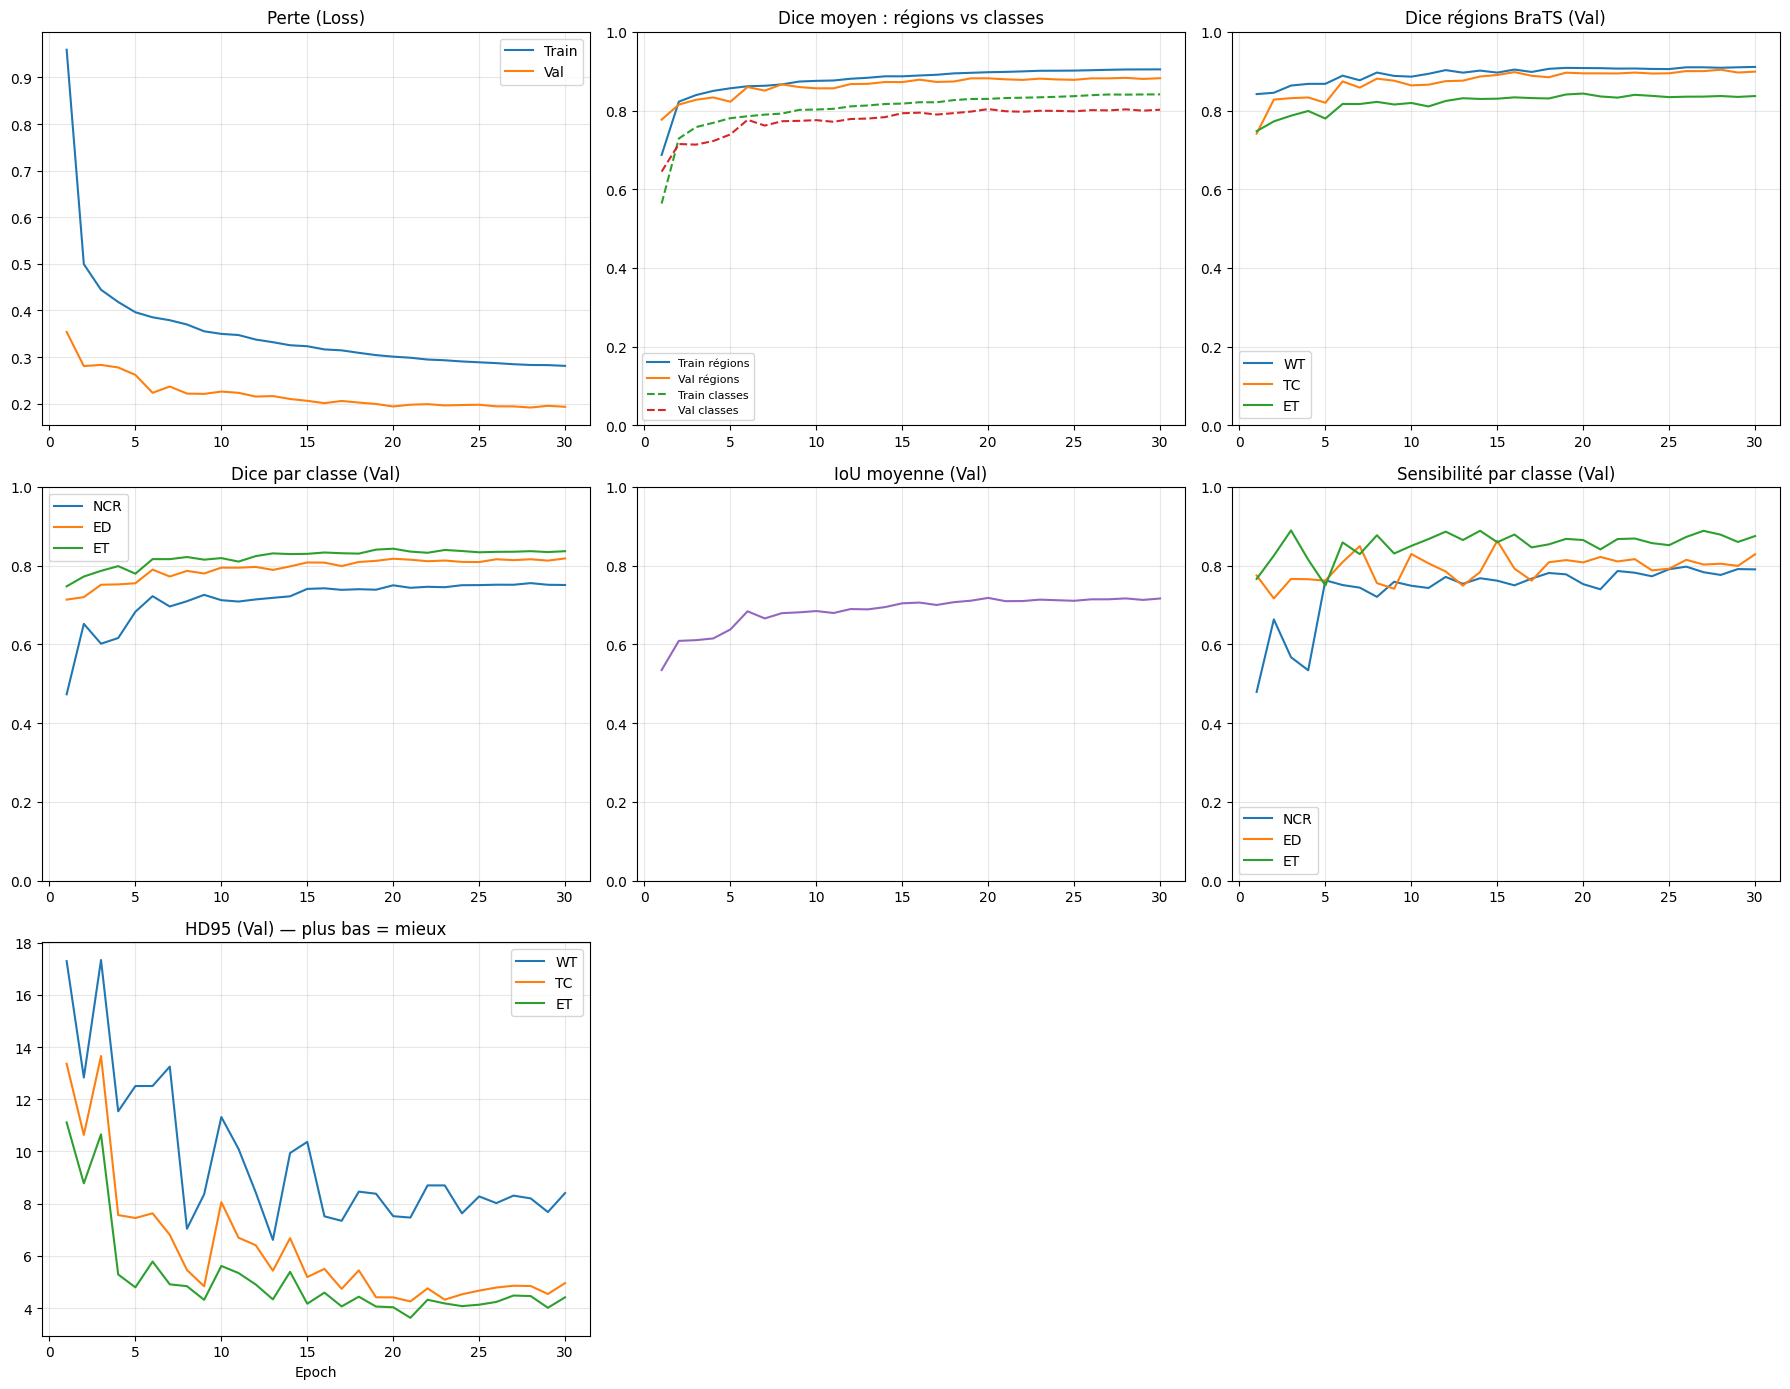

In [15]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(3, 3, figsize=(18, 14))

ax[0,0].plot(ep, history["train_loss"], label="Train"); ax[0,0].plot(ep, history["val_loss"], label="Val")
ax[0,0].set_title("Perte (Loss)"); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(ep, history["train_dice_region"], label="Train régions")
ax[0,1].plot(ep, history["val_dice_region"],   label="Val régions")
ax[0,1].plot(ep, history["train_dice_class"], "--", label="Train classes")
ax[0,1].plot(ep, history["val_dice_class"],   "--", label="Val classes")
ax[0,1].set_title("Dice moyen : régions vs classes"); ax[0,1].set_ylim(0,1); ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)

for k, lab in [("region_WT","WT"),("region_TC","TC"),("region_ET","ET")]: ax[0,2].plot(ep, history[k], label=lab)
ax[0,2].set_title("Dice régions BraTS (Val)"); ax[0,2].set_ylim(0,1); ax[0,2].legend(); ax[0,2].grid(alpha=0.3)

for k, lab in [("dice_NCR","NCR"),("dice_ED","ED"),("dice_ET","ET")]: ax[1,0].plot(ep, history[k], label=lab)
ax[1,0].set_title("Dice par classe (Val)"); ax[1,0].set_ylim(0,1); ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

ax[1,1].plot(ep, history["iou_mean"], color="tab:purple")
ax[1,1].set_title("IoU moyenne (Val)"); ax[1,1].set_ylim(0,1); ax[1,1].grid(alpha=0.3)

for k, lab in [("sens_NCR","NCR"),("sens_ED","ED"),("sens_ET","ET")]: ax[1,2].plot(ep, history[k], label=lab)
ax[1,2].set_title("Sensibilité par classe (Val)"); ax[1,2].set_ylim(0,1); ax[1,2].legend(); ax[1,2].grid(alpha=0.3)

for k, lab in [("hd95_WT","WT"),("hd95_TC","TC"),("hd95_ET","ET")]: ax[2,0].plot(ep, history[k], label=lab)
ax[2,0].set_title("HD95 (Val) — plus bas = mieux"); ax[2,0].set_xlabel("Epoch"); ax[2,0].legend(); ax[2,0].grid(alpha=0.3)
ax[2,1].axis("off"); ax[2,2].axis("off")

plt.tight_layout(); plt.savefig("/kaggle/working/training_curves.png", dpi=120); plt.show()

## 16. Visualisation des prédictions — patients les plus nets
Pour les 3 patients de validation à la tumeur la plus visible : 4 modalités + vérité terrain + prédiction.

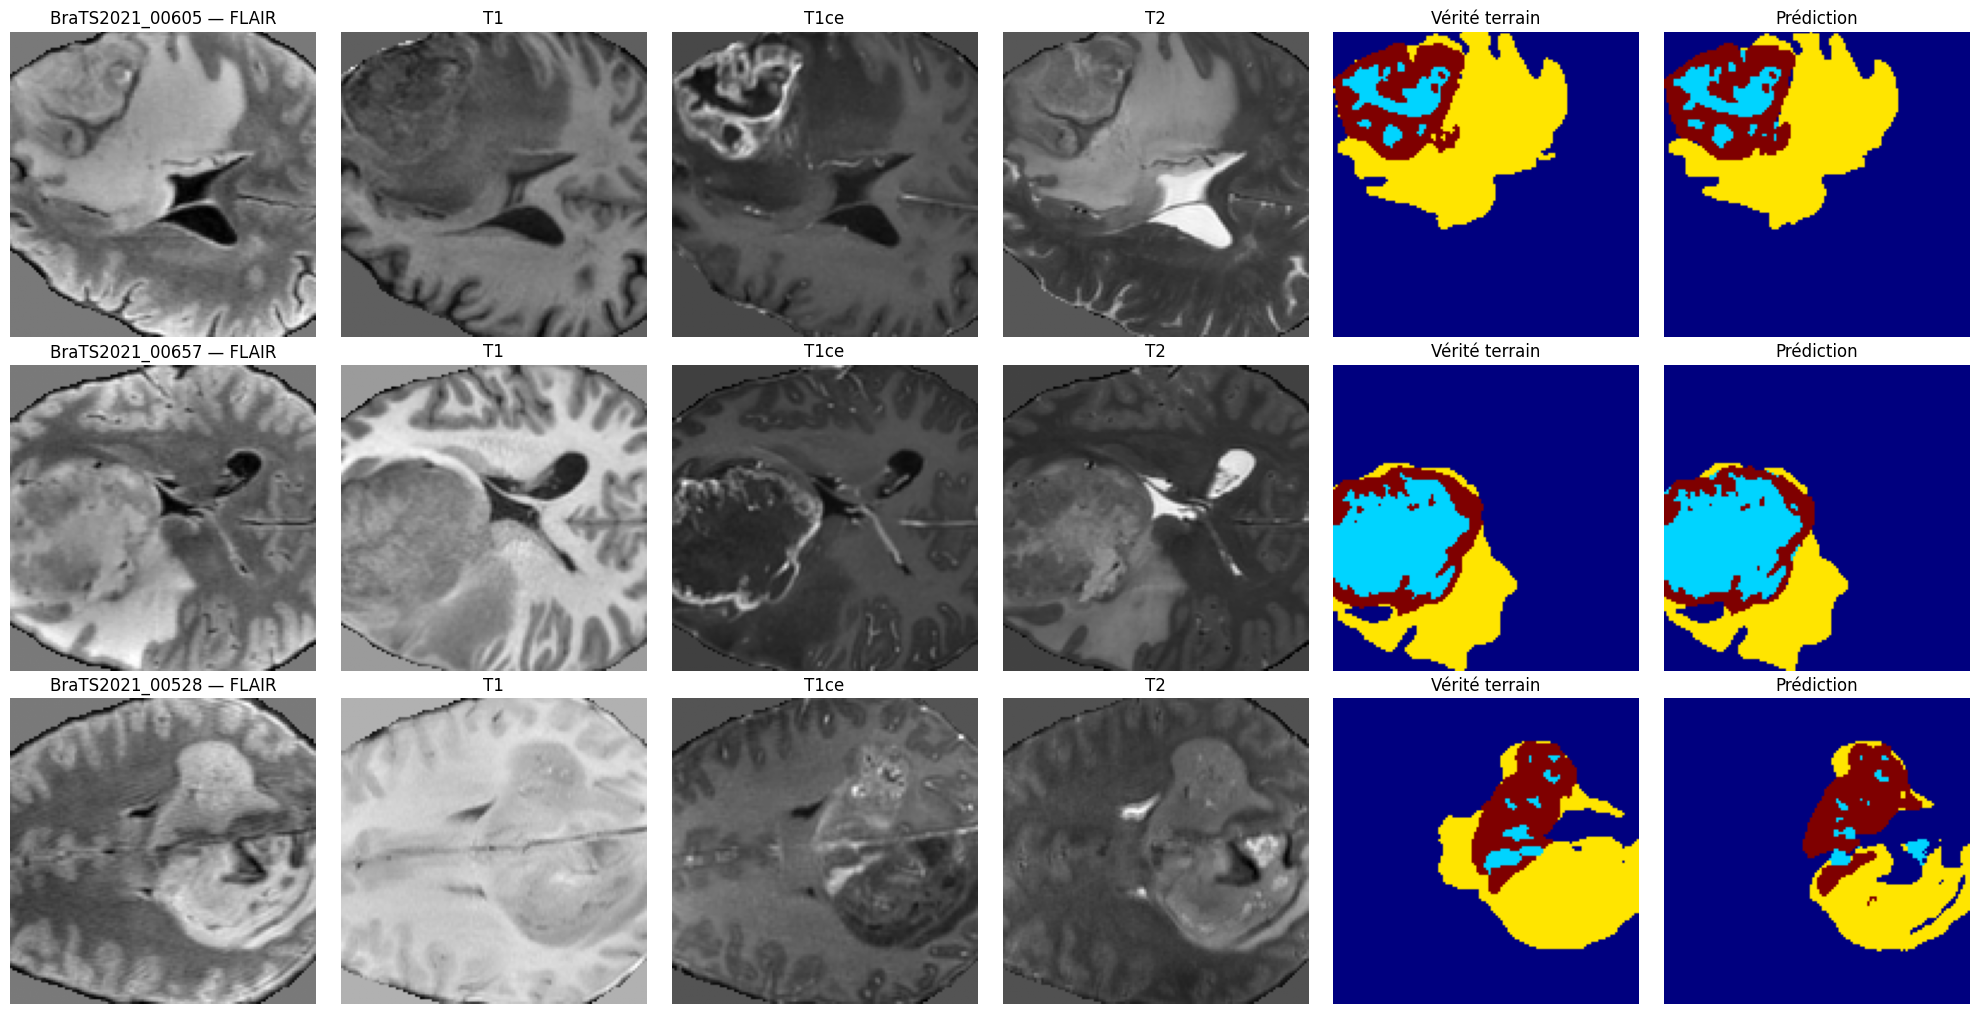

In [16]:
@torch.no_grad()
def show_predictions(n=3):
    ckpt = torch.load(cfg.CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"]); model.eval()
    idxs = pick_clear_val_indices(n)
    titles = ["FLAIR", "T1", "T1ce", "T2", "Vérité terrain", "Prédiction"]
    fig, axes = plt.subplots(len(idxs), 6, figsize=(20, 3.4 * len(idxs)))
    if len(idxs) == 1: axes = axes[None, :]
    for r, i in enumerate(idxs):
        img, seg = val_ds[i]
        with torch.amp.autocast("cuda", enabled=cfg.AMP):
            pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).squeeze(0).cpu().numpy()
        img_np, seg_np = img.numpy(), seg.numpy(); z = best_slice(seg_np)
        for c in range(4):
            axes[r, c].imshow(img_np[c, :, :, z], cmap="gray"); axes[r, c].axis("off")
            axes[r, c].set_title(f"{os.path.basename(val_folders[i])} — {titles[c]}" if c == 0 else titles[c])
        axes[r, 4].imshow(seg_np[:, :, z], cmap="jet", vmin=0, vmax=3); axes[r, 4].axis("off"); axes[r, 4].set_title(titles[4])
        axes[r, 5].imshow(pred[:, :, z],   cmap="jet", vmin=0, vmax=3); axes[r, 5].axis("off"); axes[r, 5].set_title(titles[5])
    plt.tight_layout(); plt.show()

show_predictions(n=3)

## 17. IA explicable — Grad-CAM 3D
Carte de chaleur des régions qui influencent le plus la décision (hook sur `dec1`). Rouge = forte focalisation.
Affiché sur les 3 patients les plus nets. Change `class_idx` : 1=NCR, 2=ED, 3=ET.

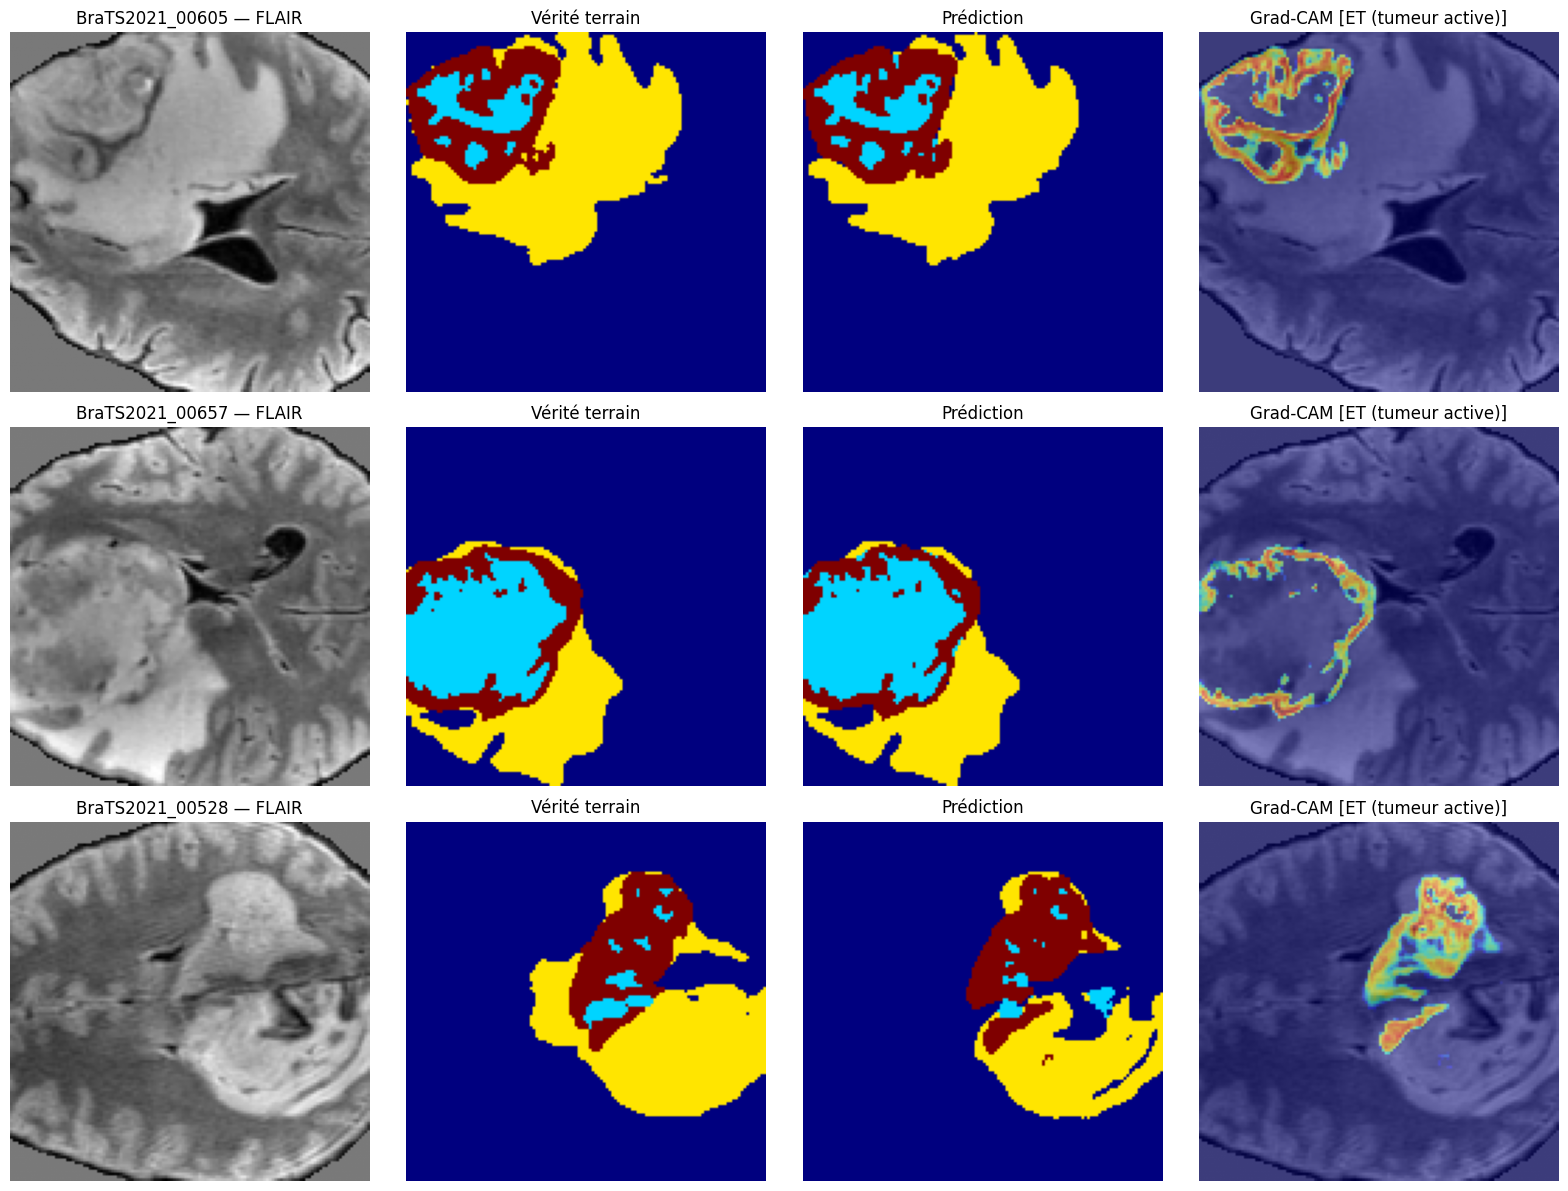

In [17]:
class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model; self.acts = None; self.grads = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, "acts", o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, "grads", go[0].detach()))
    def __call__(self, x, class_idx):
        self.model.eval(); logits = self.model(x); score = logits[:, class_idx].mean()
        self.model.zero_grad(); score.backward()
        w = self.grads.mean(dim=(2, 3, 4), keepdim=True)
        cam = F.relu((w * self.acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="trilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

CLASS_NAMES = {1: "NCR (nécrose)", 2: "ED (œdème)", 3: "ET (tumeur active)"}

def show_gradcam(n=3, class_idx=3):
    ckpt = torch.load(cfg.CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"]); model.eval()
    cam_engine = GradCAM3D(model, model.dec1)
    idxs = pick_clear_val_indices(n)
    titles = ["FLAIR", "Vérité terrain", "Prédiction", f"Grad-CAM [{CLASS_NAMES[class_idx]}]"]
    fig, axes = plt.subplots(len(idxs), 4, figsize=(16, 4 * len(idxs)))
    if len(idxs) == 1: axes = axes[None, :]
    for r, i in enumerate(idxs):
        img, seg = val_ds[i]
        x = img.unsqueeze(0).to(DEVICE).requires_grad_(True)
        with torch.no_grad():
            pred = model(x).argmax(1).squeeze(0).cpu().numpy()
        cam = cam_engine(x, class_idx)
        img_np, seg_np = img.numpy(), seg.numpy(); z = best_slice(seg_np)
        axes[r, 0].imshow(img_np[0, :, :, z], cmap="gray")
        axes[r, 1].imshow(seg_np[:, :, z], cmap="jet", vmin=0, vmax=3)
        axes[r, 2].imshow(pred[:, :, z], cmap="jet", vmin=0, vmax=3)
        axes[r, 3].imshow(img_np[0, :, :, z], cmap="gray"); axes[r, 3].imshow(cam[:, :, z], cmap="jet", alpha=0.5)
        for c in range(4):
            axes[r, c].axis("off")
            axes[r, c].set_title(f"{os.path.basename(val_folders[i])} — {titles[c]}" if c == 0 else titles[c])
    plt.tight_layout(); plt.savefig("/kaggle/working/gradcam.png", dpi=120); plt.show()

show_gradcam(n=3, class_idx=3)

## 18. Sauvegarde du modèle entraîné

In [18]:
FINAL_PATH = "/kaggle/working/hmsa_unet3d_final.pth"
if os.path.exists(cfg.CKPT_PATH):
    shutil.copy(cfg.CKPT_PATH, FINAL_PATH)
    ckpt = torch.load(FINAL_PATH, map_location="cpu", weights_only=False)
    print("Modèle sauvegardé :")
    print("  - Meilleur (auto) :", cfg.CKPT_PATH)
    print("  - Copie finale    :", FINAL_PATH)
    print(f"  - Epoch {ckpt['epoch']} | Dice régions BraTS {ckpt['best_dice']:.4f}")
    print("Télécharge-le depuis l'onglet 'Output' du notebook Kaggle.")
else:
    print("Aucun checkpoint : lance d'abord l'entraînement (cellule 14).")

# Recharger plus tard :
# ckpt = torch.load(FINAL_PATH, map_location=DEVICE, weights_only=False)
# model.load_state_dict(ckpt["model"]); model.eval()

Modèle sauvegardé :
  - Meilleur (auto) : /kaggle/working/hmsa_unet3d_best.pth
  - Copie finale    : /kaggle/working/hmsa_unet3d_final.pth
  - Epoch 28 | Dice régions BraTS 0.8831
Télécharge-le depuis l'onglet 'Output' du notebook Kaggle.
